In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../'))

import numpy as np
import tensorflow as tf
import random, json

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

2026-05-14 16:14:25.925898: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778775265.947390    1814 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778775265.954425    1814 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778775265.971777    1814 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778775265.971798    1814 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778775265.971800    1814 computation_placer.cc:177] computation placer alr

In [2]:
from src.pipeline.captioning_scratch import ImageCaptionerScratch
from src.pipeline.captioning_keras import ImageCaptionerKeras
from src.evaluation.metrics import compute_bleu4, compute_meteor, timed_predict_from_features

VOCAB_PATH          = '../../data/captions/vocab.json'
TEST_CAPTIONS_PATH  = '../../data/captions/test_captions.json'
TEST_FEATURES_PATH  = '../../data/features/test_features.npy'

with open(TEST_CAPTIONS_PATH) as f:
    test_data = json.load(f)

test_image_names = list(test_data.keys())
test_references  = [test_data[name] for name in test_image_names]

test_features = np.load(TEST_FEATURES_PATH, allow_pickle=True).item()
if isinstance(test_features, dict):
    test_feat_matrix = np.stack([test_features[n] for n in test_image_names])
else:
    test_feat_matrix = test_features

print(f'Test set: {len(test_image_names)} images')

Test set: 1012 images


In [3]:
BEST_RNN_WEIGHTS  = '../../weights/rnn_lstm/rnn_preinject_L2_H512.h5'   
BEST_LSTM_WEIGHTS = '../../weights/rnn_lstm/lstm_preinject_L3_H512.h5'  

BEST_RNN_LABEL  = 'rnn_2layer_512'   
BEST_LSTM_LABEL = 'lstm_3layer_512'

In [4]:
def evaluate(captioner, feat_matrix, references, max_len=20):
    captions, total, avg = timed_predict_from_features(captioner, feat_matrix, max_len)
    return {
        'bleu4':   compute_bleu4(references, captions),
        'meteor':  compute_meteor(references, captions),
        'avg_time': avg,
        'captions': captions,
    }

# RNN from scratch
rnn_scratch = ImageCaptionerScratch('rnn')
rnn_scratch.load_weights('InceptionV3', BEST_RNN_WEIGHTS, VOCAB_PATH)
res_rnn_scratch = evaluate(rnn_scratch, test_feat_matrix, test_references)
print(f'RNN  Scratch  BLEU-4={res_rnn_scratch["bleu4"]:.4f}  METEOR={res_rnn_scratch["meteor"]:.4f}  avg={res_rnn_scratch["avg_time"]:.3f}s')

# LSTM from scratch
lstm_scratch = ImageCaptionerScratch('lstm')
lstm_scratch.load_weights('InceptionV3', BEST_LSTM_WEIGHTS, VOCAB_PATH)
res_lstm_scratch = evaluate(lstm_scratch, test_feat_matrix, test_references)
print(f'LSTM Scratch  BLEU-4={res_lstm_scratch["bleu4"]:.4f}  METEOR={res_lstm_scratch["meteor"]:.4f}  avg={res_lstm_scratch["avg_time"]:.3f}s')

# RNN Keras
rnn_keras = ImageCaptionerKeras('rnn')
rnn_keras.load_model('InceptionV3', BEST_RNN_WEIGHTS, VOCAB_PATH)
res_rnn_keras = evaluate(rnn_keras, test_feat_matrix, test_references)
print(f'RNN  Keras    BLEU-4={res_rnn_keras["bleu4"]:.4f}  METEOR={res_rnn_keras["meteor"]:.4f}  avg={res_rnn_keras["avg_time"]:.3f}s')

# LSTM Keras
lstm_keras = ImageCaptionerKeras('lstm')
lstm_keras.load_model('InceptionV3', BEST_LSTM_WEIGHTS, VOCAB_PATH)
res_lstm_keras = evaluate(lstm_keras, test_feat_matrix, test_references)
print(f'LSTM Keras    BLEU-4={res_lstm_keras["bleu4"]:.4f}  METEOR={res_lstm_keras["meteor"]:.4f}  avg={res_lstm_keras["avg_time"]:.3f}s')

I0000 00:00:1778775276.112077    1814 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5447 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778775276.117182    1814 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13655 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


RNN  Scratch  BLEU-4=0.0048  METEOR=0.1480  avg=0.015s


LSTM Scratch  BLEU-4=0.0028  METEOR=0.1487  avg=0.060s


I0000 00:00:1778775374.219423    1861 service.cc:152] XLA service 0x1e2362c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778775374.219470    1861 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778775374.219477    1861 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778775374.298222    1861 cuda_dnn.cc:529] Loaded cuDNN version 91002


I0000 00:00:1778775374.844537    1861 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


RNN  Keras    BLEU-4=0.0048  METEOR=0.1480  avg=0.575s


LSTM Keras    BLEU-4=0.0028  METEOR=0.1487  avg=0.669s


In [5]:
import pandas as pd

comparison = [
    {'model': f'RNN-Scratch ({BEST_RNN_LABEL})',   **{k: round(v, 4) for k, v in res_rnn_scratch.items()  if k != 'captions'}},
    {'model': f'RNN-Keras   ({BEST_RNN_LABEL})',   **{k: round(v, 4) for k, v in res_rnn_keras.items()    if k != 'captions'}},
    {'model': f'LSTM-Scratch ({BEST_LSTM_LABEL})', **{k: round(v, 4) for k, v in res_lstm_scratch.items() if k != 'captions'}},
    {'model': f'LSTM-Keras   ({BEST_LSTM_LABEL})', **{k: round(v, 4) for k, v in res_lstm_keras.items()   if k != 'captions'}},
]
df_cmp = pd.DataFrame(comparison)
display(df_cmp)

import json, os
os.makedirs('../../results/tables', exist_ok=True)
with open('../../results/tables/keras_vs_scratch.json', 'w') as f:
    json.dump([{k: v for k, v in r.items() if k != 'captions'} for r in comparison], f, indent=2)

,model,bleu4,meteor,avg_time
0,RNN-Scratch (rnn_2layer_512),0.0048,0.1480,0.0148
1,RNN-Keras (rnn_2layer_512),0.0048,0.1480,0.5746
2,LSTM-Scratch (lstm_3layer_512),0.0028,0.1487,0.0601
3,LSTM-Keras (lstm_3layer_512),0.0028,0.1487,0.6691


/tmp/ipykernel_1814/2382392343.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_1814/2382392343.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_1814/2382392343.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=25, ha='right', fontsize=8)


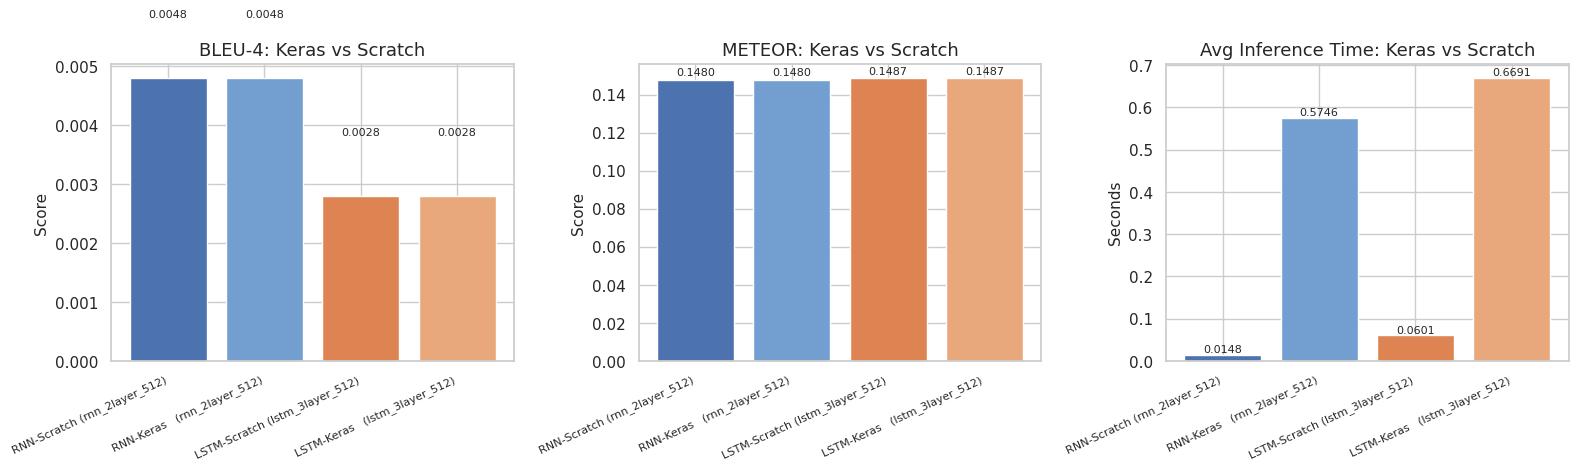

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns, os

sns.set_theme(style='whitegrid')
os.makedirs('../../results/plots', exist_ok=True)

models  = [r['model'] for r in comparison]
bleu4s  = [r['bleu4']    for r in comparison]
meteors = [r['meteor']   for r in comparison]
times   = [r['avg_time'] for r in comparison]
colors  = ['#4C72B0', '#729FCF', '#DD8452', '#E8A87C']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, vals, title, ylabel in [
    (axes[0], bleu4s,  'BLEU-4',  'Score'),
    (axes[1], meteors, 'METEOR',  'Score'),
    (axes[2], times,   'Avg Inference Time', 'Seconds'),
]:
    bars = ax.bar(models, vals, color=colors)
    ax.set_title(f'{title}: Keras vs Scratch', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../../results/plots/keras_vs_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

## Analisis

**1. Perbedaan score Keras vs from-scratch:**

**2. Waktu inferensi:**